# **Taller Práctico: Análisis de Series de Tiempo Financieras como Procesos Estocásticos**

**Estudiante:** Brayan Stiven Lopez Mendez  
**Código estudiantil:** 224393004

Maestría en Ingeniería Electrónica

Universidad de Nariño Curso

Introducción a la Ciencia de Datos

Instructor: Carlos Andrés Viteri Mera


En este cuaderno construiremos un marco empírico para analizar datos del mercado de valores, específicamente el índice S&P 500, tratándolo como un proceso estocástico en tiempo discreto $X[n]$.
De acuerdo con la teoría de procesos estocásticos, cada resultado de un experimento se mapea a una colección de variables aleatorias en el tiempo. Aquí, consideraremos que cada año (de 1970 a 2025) es una realización empírica independiente (o trayectoria) del proceso, y los días de cotización representan el índice de tiempo discreto $n$.
Para que todas las trayectorias partan del mismo estado inicial, normalizaremos cada año dividiendo todos sus valores por el valor de cierre del primer día del año, asegurando que $X[0]=1$.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# **1. Adquisición y Preparación del Dataset (Data Wrangling)**
Extraeremos el histórico del índice S&P 500 (^GSPC) desde el primero de enero de 1970. Dado que un año financiero típico tiene aproximadamente 252 días de cotización, extraeremos los primeros 250 días de cada año para formar una matriz homogénea de dimensión $M \times N$, donde $M$ es el número de años (realizaciones) y $N=250$ el número de instantes de tiempo.

[*********************100%***********************]  1 of 1 completed


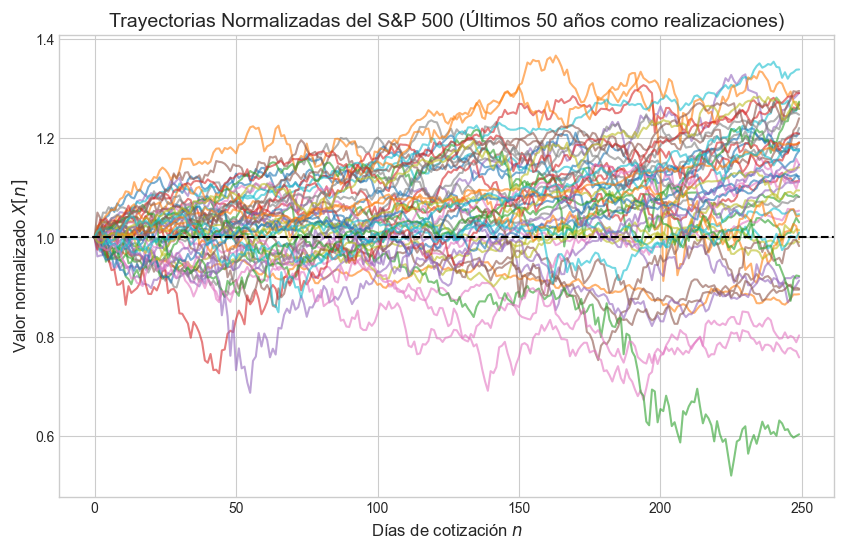

In [2]:
# 1. Descarga de datos
ticker = '^GSPC'
df_sp500 = yf.download(ticker, start='1970-01-01', end='2025-12-31')

# Usamos la columna 'Close' para el cierre diario
# Si yfinance devuelve un MultiIndex, lo aplanamos
if isinstance(df_sp500.columns, pd.MultiIndex):
    precios = df_sp500['Close'].squeeze()
else:
    precios = df_sp500['Close']

# 2. Agrupación por año y construcción del ensamble de trayectorias
years = range(1970, 2026)
N_dias = 250 # Fijamos 250 días de cotización por año para tener una matriz uniforme
M = len(years)

# Matriz que contendrá el proceso estocástico X_n
X = np.zeros((M, N_dias))

for i, year in enumerate(years):
    # Extraemos los precios del año correspondiente
    datos = precios[precios.index.year == year].values

    # Verificamos que haya suficientes datos
    if len(datos) > N_dias:
        # Se recordan los datos a N_dias
        X[i, :] = datos[:N_dias]

    elif len(datos) < N_dias: # Si tiene menos de 250 días, rellenamos con el último valor
        # np.pad agrega 0 datos al inicio y N_dias - len(datos) datos al final
        # La opción 'edge' rellena con el último valor encontrado en la serie
        X[i, :] = np.pad(datos, (0, N_dias - len(datos)), 'edge')

    else:
        X[i, :] = datos

    # Normalización: X[n] = Precio[n] / Precio[0]
    X[i, :] = X[i, :]/X[i, 0]

# Visualización de un subconjunto de trayectorias (ej. últimas 50 realizaciones)
plt.figure(figsize=(10, 6))
for i in range(max(0, M-50), M):
    plt.plot(range(N_dias), X[i, :], alpha=0.6, lw=1.5)

plt.title('Trayectorias Normalizadas del S&P 500 (Últimos 50 años como realizaciones)', fontsize=14)
plt.xlabel('Días de cotización $n$', fontsize=12)
plt.ylabel('Valor normalizado $X[n]$', fontsize=12)
plt.axhline(1.0, color='black', linestyle='--')
plt.show()

# **Reto 1: Caracterización de Primer Orden (Estimación de PDFs)**
Para un tiempo discreto fijo $n$, $X[n]$ representa una variable aleatoria caracterizada por su función de densidad de probabilidad $f_X​(x,n)$.
Tu tarea:
1. Seleccione los datos del ensamble (la matriz X) para los instantes de tiempo (días) n=1, n=100 y n=200.
2. Estime y grafique la PDF para cada uno de estos días en una misma figura con 3 subgráficos (puedes usar sns.histplot con la opción kde=True).
3. Análisis: Observe las tres gráficas. ¿Qué sucede con la dispersión (varianza) de los posibles valores del índice a medida que avanza el año? Argumenta tu respuesta en una celda de texto.

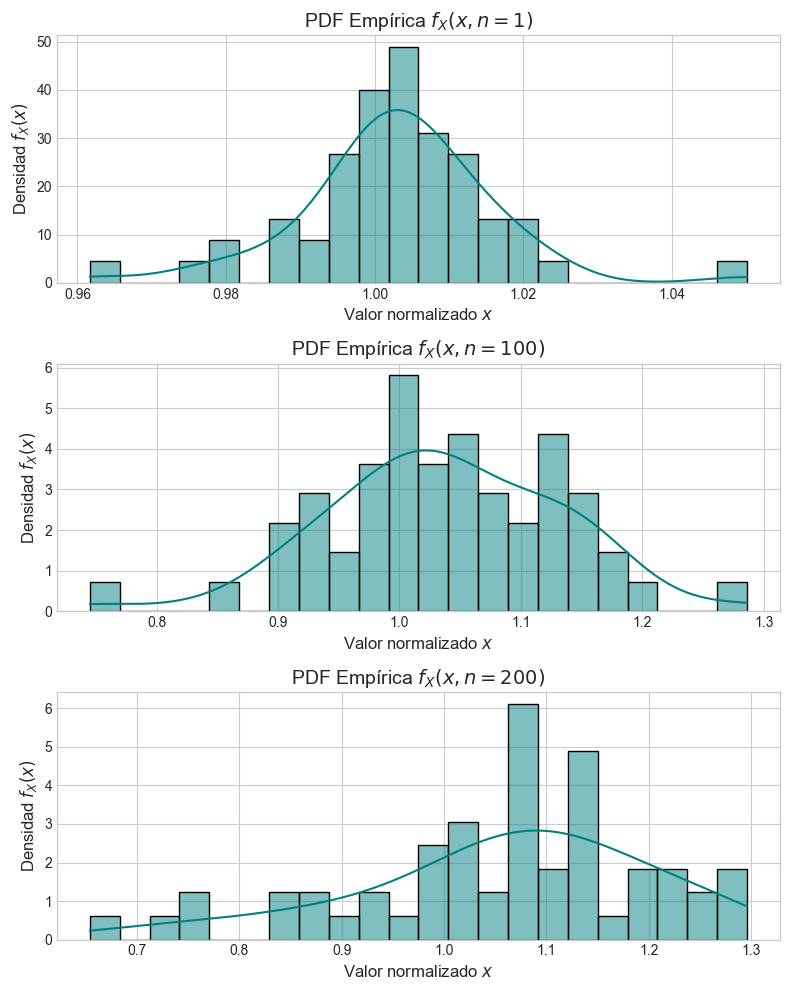

ρ entre pares X[n], X[m] (cada fila = un año; asociación lineal transversal):
  ρ(X[1], X[100]) = 0.118326
  ρ(X[1], X[200]) = -0.070000
  ρ(X[100], X[200]) = 0.734588


In [3]:
# Reto 1: Caracterización de Primer Orden (Estimación de PDFs)
# Seleccionamos los datos para n=1, n=100 y n=200
n_valores = [1, 100, 200]

fig, axes = plt.subplots(3, 1, figsize=(8, 10))

for i, n in enumerate(n_valores):
    
    X_en_n = X[:, n]

    # Estimamos la PDF empírica usando histograma y KDE
    sns.histplot(X_en_n, stat="density", kde=True, ax=axes[i], color='teal', bins=22, kde_kws={"bw_adjust": 1.0})

    axes[i].set_title(f'PDF Empírica $f_X(x, n={n})$', fontsize=14)
    axes[i].set_xlabel('Valor normalizado $x$', fontsize=12)
    axes[i].set_ylabel('Densidad $f_X(x)$', fontsize=12)
    

plt.tight_layout()
plt.show()

# Pearson entre pares (transversal): convención poblacional ddof=0, coherente con Retos 3–4
def _rho_poblacional(u, v):
    su, sv = np.std(u, ddof=0), np.std(v, ddof=0)
    if su * sv <= 1e-20:
        return float("nan")
    return np.mean((u - u.mean()) * (v - v.mean())) / (su * sv)

idx_pdf = [1, 100, 200]
print("ρ entre pares X[n], X[m] (cada fila = un año; asociación lineal transversal):")
for ia, a in enumerate(idx_pdf):
    for b in idx_pdf[ia + 1 :]:
        ra, rb = X[:, a], X[:, b]
        print(f"  ρ(X[{a}], X[{b}]) = {_rho_poblacional(ra, rb):.6f}")


### Análisis — Reto 1 (precios normalizados)

En $n=1$ la masa de probabilidad está muy concentrada cerca de $x=1$ (pocos días de trading, poca dispersión entre años). Al avanzar a $n=100$ y $n=200$, el histograma se **ensancha**: la varianza transversal del ensamble **aumenta** con $n$. Esto refleja que, manteniendo $X[0]=1$, las trayectorias **divergen** a lo largo del año: la incertidumbre acumulada sobre el nivel del índice (normalizado) crece con el tiempo dentro de cada realización anual.

**Correlación de Pearson (Reto 1):** entre dos días $n$ y $m$ fijos, $\rho$ se calcula sobre las $M$ realizaciones $(X_i[n], X_i[m])$ (mismo año $i$). Valores cercanos a 1 indican que años con índice alto en el día $n$ tienden a estarlo también en el día $m$ (dependencia lineal **transversal**). No confundir con la autocorrelación temporal de **una** trayectoria; aquí el ensamble son años distintos ([definición](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient): $\rho=\mathrm{Cov}(U,V)/(\sigma_U\sigma_V)$). Los valores impresos en consola usan covarianza y desviaciones **poblacionales** sobre el ensamble (`ddof=0`), la misma convención que en los Retos 3–4.



# **Reto 2: Valor Esperado y Varianza del Proceso Estocástico**
El primer momento probabilístico o valor esperado del proceso se define como $\mu[n]=E\{X[n]\}$. Su varianza se define como $\mathrm{var}\{X[n]\}=\mathbf{E}\{(X[n]−\mu[n])^2\}$. La tarea:

1. Calcule empíricamente el valor esperado $\mu[n]$ promediando a través del ensamble (las $M$ realizaciones) para cada uno de los $N$ días.
2. Calcule empíricamente la varianza transversal para cada uno de los $N$ días.
3. Grafique el valor esperado empírico $\mu[n]$ en función de $n$ (días de cotización). Añade una línea de referencia en el nivel base $X[0]=1$.
4. Grafique la varianza empírica en función de $n$ en otro panel.
5. Análisis: Un proceso es Estacionario en Sentido Amplio (WSS) si su valor esperado es constante en el tiempo y su función de autocorrelación depende únicamente de la diferencia de tiempo $\tau$. Basado en las gráficas, ¿el índice S&P 500 puede modelarse como un proceso estocástico WSS? ¿Por qué?

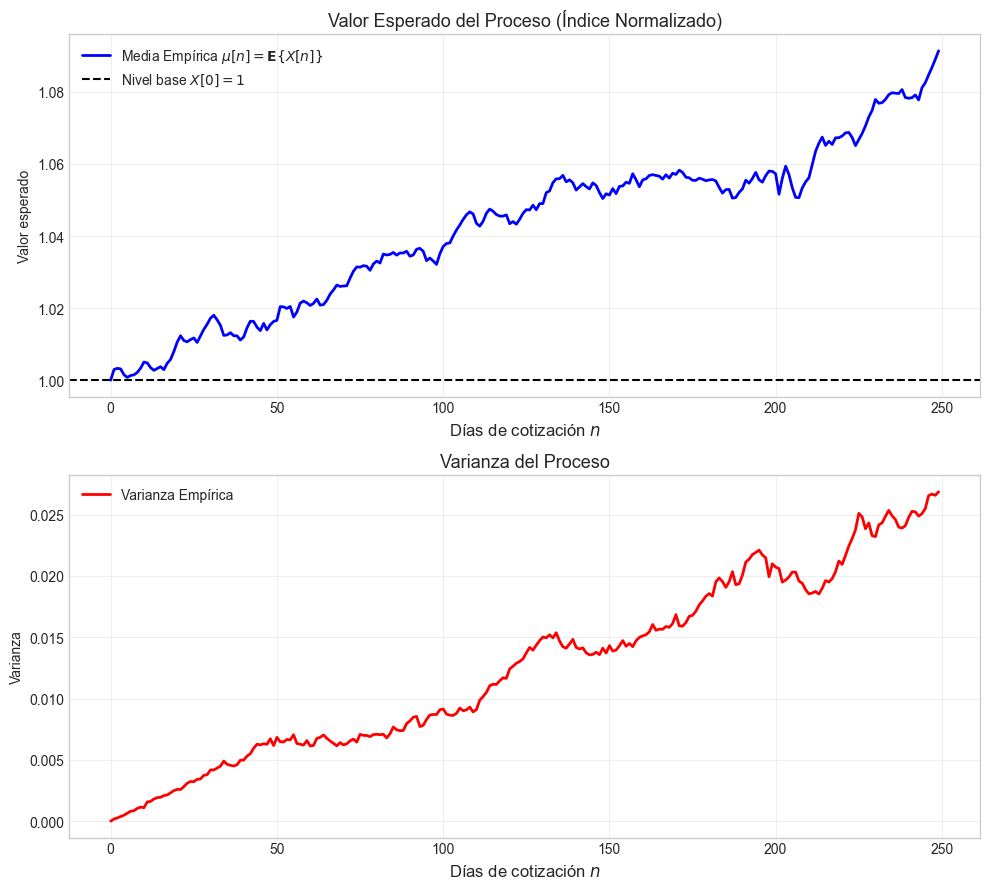

ρ( n , μ[n] ) = 0.971213
ρ( n , Var(X[n]) ) = 0.987118


In [4]:
# Reto 2: Valor Esperado y Varianza del Proceso Estocástico
# 1. Valor esperado empírico (media transversal sobre las M realizaciones)
mu_empirica = np.mean(X, axis=0)

# 2. Varianza empírica transversal para cada uno de los N días
var_empirica = np.var(X, axis=0)

n_array = np.arange(N_dias)

# 3. Gráfica del valor esperado con línea de referencia X[0]=1
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9))

ax1.plot(n_array, mu_empirica, label=r'Media Empírica $\mu[n] = \mathbf{E}\{X[n]\}$', color='blue', lw=2)
ax1.axhline(1.0, color='black', linestyle='--', label='Nivel base $X[0]=1$')
ax1.set_title('Valor Esperado del Proceso (Índice Normalizado)', fontsize=13)
ax1.set_xlabel('Días de cotización $n$', fontsize=12)
ax1.set_ylabel('Valor esperado')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 4. Gráfica de la varianza empírica
ax2.plot(n_array, var_empirica, label='Varianza Empírica', color='red', lw=2)
ax2.set_title('Varianza del Proceso', fontsize=13)
ax2.set_xlabel('Días de cotización $n$', fontsize=12)
ax2.set_ylabel('Varianza')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Pearson entre el índice de día n y las curvas μ[n] y Var(X[n]): mide tendencia lineal vs el tiempo dentro del año
n_f = np.arange(N_dias, dtype=float)
print(f"ρ( n , μ[n] ) = {np.corrcoef(n_f, mu_empirica)[0, 1]:.6f}")
print(f"ρ( n , Var(X[n]) ) = {np.corrcoef(n_f, var_empirica)[0, 1]:.6f}")


### Análisis — Reto 2 (¿WSS para precios normalizados?)

**No** es razonable modelar este proceso como WSS (sentido amplio). En las gráficas, $\mu[n]$ **no es constante**: crece con $n$ (tendencia alcista histórica promedio una vez fijado el arranque en $X[0]=1$). La varianza $\mathrm{var}\{X[n]\}$ tampoco es constante: es nula en $n=0$ por construcción y **crece** al avanzar el año. Un proceso WSS exigiría media constante y autocorrelación que solo dependa del desfase $\tau$; aquí el índice $n$ es el **día dentro del año** y tanto la media como la varianza empíricas dependen claramente de $n$, coherente con una matriz de autocovarianza (Reto 4) que no es una función únicamente de $|n_1-n_2|$.

**Pearson (Reto 2):** $\rho(n,\mu[n])$ y $\rho(n,\mathrm{Var}(X[n]))$ miden si la media y la varianza **cambian de forma aproximadamente lineal** con el día del año. Valores con $|{\rho}|$ altos respaldan visualmente que el proceso **no** es WSS (media/varianza no constantes frente a $n$). En consola se usa `np.corrcoef` (estimador muestral estándar de Pearson entre dos vectores); con $M$ moderado la diferencia frente a `ddof=0` es pequeña y solo sirve como **índice descriptivo** de tendencia, no como covarianza del proceso en el sentido estricto.



# **Reto 3: Función de Autocorrelación y Autocovarianza para $n_1​=100$**

1. Fije el día de referencia $n_1​=100$. Calcule un arreglo con la autocorrelación empírica $R_{XX}​(100,n_2​)$ barriendo todos los días $n_2\in{0,…,249}$.
2. Calcule un arreglo con la autocovarianza empírica $C_{XX}​(100,n_2​)$ para los mismos valores de $n_2$​.
3. Grafique ambas funciones en un mismo plano. Señale con una línea vertical el instante $n_1​=100$.
4. Análisis: ¿Cuál es la relación teórica entre la función de autocovarianza $C_{XX}​(n_1​,n_2​)$ evaluada en $n_1​=n_2​=100$ y la varianza del proceso en ese mismo instante calculada en el Reto 2? Verifique empíricamente si los valores coinciden.

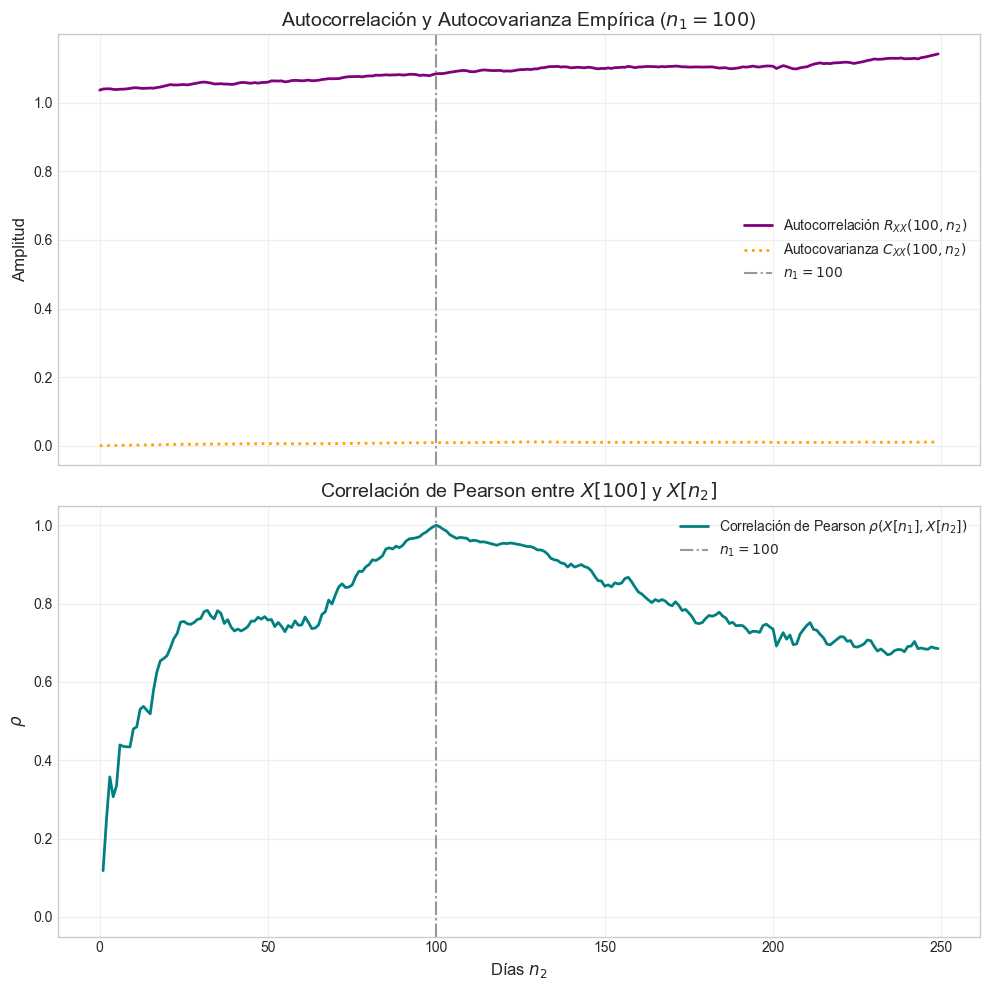

C_XX(100, 100) = 0.009147
Var(X[100]) del Reto 2 = 0.009147
¿Coinciden? True
  n2=50: ρ=0.757669, C_XX/(σ100·σn2)=0.757669
  n2=150: ρ=0.844308, C_XX/(σ100·σn2)=0.844308
  n2=249: ρ=0.685115, C_XX/(σ100·σn2)=0.685115


In [5]:
# Reto 3: Autocorrelación, Autocovarianza y Correlación de Pearson para n1=100
n1 = 100

# 1. Arreglos para R_XX(100, n2), C_XX(100, n2) y ρ (Pearson)
R_XX = np.zeros(N_dias)
C_XX = np.zeros(N_dias)
rho_empirica = np.full(N_dias, np.nan)

for n2 in range(N_dias):
    # Autocorrelación: R_XX(n1,n2) = E[X[n1]*X[n2]]
    R_XX[n2] = np.mean(X[:, n1] * X[:, n2])

    # Autocovarianza: C_XX(n1,n2) = R_XX(n1,n2) - μ[n1]*μ[n2]
    C_XX[n2] = R_XX[n2] - (mu_empirica[n1] * mu_empirica[n2])

    # Pearson (poblacional sobre el ensamble): ρ = C_XX / (σ_{n1} σ_{n2}), alineado con np.var/ddof=0
    s1 = np.std(X[:, n1], ddof=0)
    s2 = np.std(X[:, n2], ddof=0)
    if s1 > 1e-20 and s2 > 1e-20:
        rho_empirica[n2] = C_XX[n2] / (s1 * s2)

# 3. Gráficas: Autocorrelación/Autocovarianza y Correlación de Pearson
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

ax1.plot(range(N_dias), R_XX, label=r'Autocorrelación $R_{XX}(100, n_2)$', color='purple', lw=2)
ax1.plot(range(N_dias), C_XX, label=r'Autocovarianza $C_{XX}(100, n_2)$', color='orange', linestyle=':', lw=2)
ax1.axvline(n1, color='gray', linestyle='-.', alpha=0.8, label=f'$n_1 = {n1}$')
ax1.set_title(f'Autocorrelación y Autocovarianza Empírica ($n_1 = {n1}$)', fontsize=14)
ax1.set_ylabel('Amplitud', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(range(N_dias), rho_empirica, label=r'Correlación de Pearson $\rho(X[n_1], X[n_2])$', color='teal', lw=2)
ax2.axvline(n1, color='gray', linestyle='-.', alpha=0.8, label=f'$n_1 = {n1}$')
ax2.set_title(f'Correlación de Pearson entre $X[{n1}]$ y $X[n_2]$', fontsize=14)
ax2.set_xlabel('Días $n_2$', fontsize=12)
ax2.set_ylabel(r'$\rho$', fontsize=12)
ax2.set_ylim(-0.05, 1.05)
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Análisis: Relación teórica C_XX(n1,n1) = Var(X[n1])
print(f"C_XX(100, 100) = {C_XX[n1]:.6f}")
print(f"Var(X[100]) del Reto 2 = {var_empirica[n1]:.6f}")
print(f"¿Coinciden? {np.isclose(C_XX[n1], var_empirica[n1])}")

# Chequeo ρ = C_XX/(σ100 σ n2) en un par de puntos (misma convención poblacional)
std_n1 = np.std(X[:, n1], ddof=0)
for n_test in (0, 50, 150, 249):
    st = np.std(X[:, n_test], ddof=0)
    if st > 1e-20:
        print(f"  n2={n_test}: ρ={rho_empirica[n_test]:.6f}, C_XX/(σ100·σn2)={C_XX[n_test]/(std_n1*st):.6f}")


### Análisis — Reto 3 (relación $C_{XX}(100,100)$ y varianza)

Teóricamente, $C_{XX}(n_1,n_2)=\mathbf{E}\{(X[n_1]-\mu[n_1])(X[n_2]-\mu[n_2])\}$, luego $C_{XX}(n_1,n_1)=\mathbf{E}\{(X[n_1]-\mu[n_1])^2\}=\mathrm{var}\{X[n_1]\}$. La autocovarianza en la diagonal coincide con la varianza del proceso en ese instante. Los valores impresos arriba deben coincidir numéricamente (salvo redondeo) porque se usa la misma definición (promedio sobre el ensamble) que en el Reto 2; `np.cov(..., ddof=0)` alinea la diagonal de la matriz del Reto 4 con `np.var(...)` del Reto 2.

**Correlación de Pearson (Reto 3):** para cada $n_2$, $\rho(X[n_1],X[n_2]) = C_{XX}(n_1,n_2)\big/\big(\sigma_{X[n_1]}\sigma_{X[n_2]}\big)$ (covarianza y desviaciones **poblacionales** sobre el ensamble de años, coherente con el Reto 2). Así $\rho$ es una **normalización adimensional** de la autocovarianza; la curva de abajo muestra la misma dependencia que $C_{XX}$ pero en $[-1,1]$ ([Wikipedia: Pearson correlation](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient)).



# **Reto 4: Matriz de Autocovarianza**
1. Calcule la matriz de autocovarianza empírica completa a partir de la matriz de realizaciones $X$. (Pista: np.cov es útil, pero asegúrese de definir correctamente si las variables están en las filas o en las columnas usando el argumento rowvar). El resultado debe ser una matriz de dimensión $250\times 250$.
2. Grafique esta matriz como un mapa de calor 2D (heatmap). Puede usar plt.imshow, sns.heatmap o plt.pcolormesh.
3. Asegúrate de incluir una barra de colores (colorbar) e identificar correctamente los ejes $n_1​$ y $n_2$​.
4. Análisis: Observe la diagonal principal del mapa de calor (donde $n_1​=n_2$​). ¿Qué estadística del proceso representa esta diagonal y cómo concuerda su evolución de color con la gráfica de varianza que obtuvo en el Reto 2?

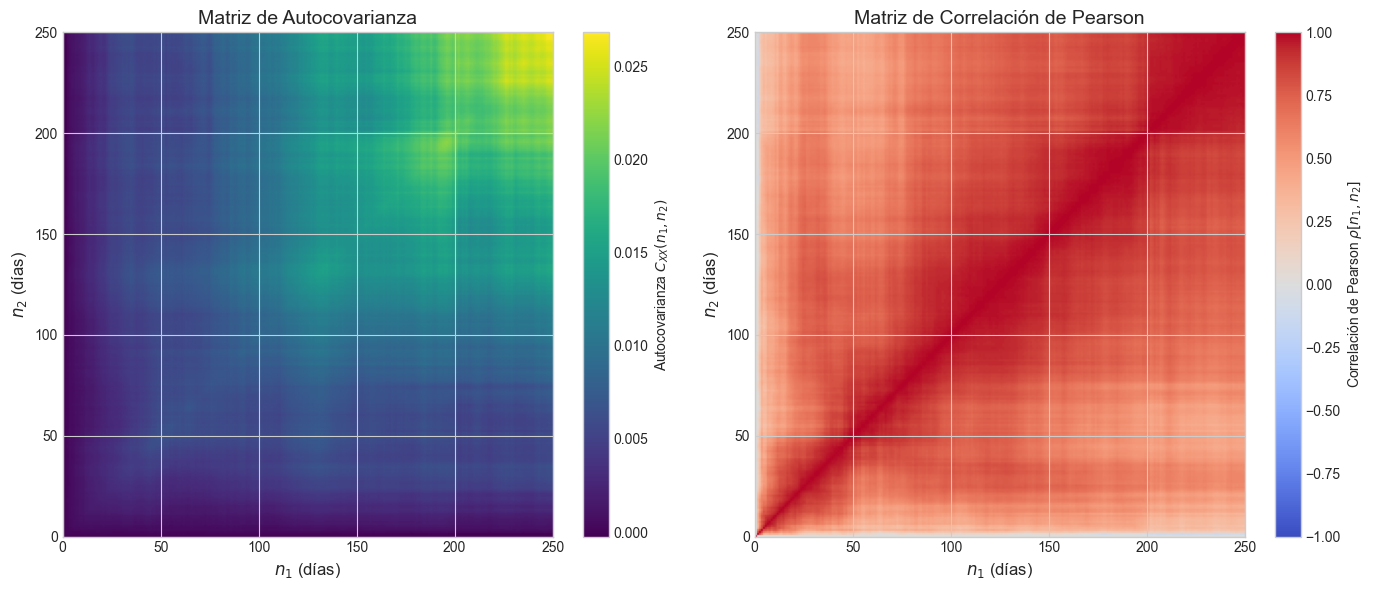

In [6]:
# Reto 4: Matriz de Autocovarianza y Matriz de Correlación de Pearson
# 1. Matriz de autocovarianza y de correlación de Pearson (250 x 250)
C_XX_matriz = np.cov(X, rowvar=False, ddof=0)
# Matriz de Pearson coherente con C_XX: ρ_ij = C_ij / (σ_i σ_j)  (evita mezclar ddof con np.corrcoef)
sig = np.sqrt(np.clip(np.diag(C_XX_matriz), 1e-30, None))
Rho_matriz = C_XX_matriz / np.outer(sig, sig)
np.fill_diagonal(Rho_matriz, 1.0)

# 2. Heatmaps lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(C_XX_matriz, origin='lower', cmap='viridis',
                     extent=[0, N_dias, 0, N_dias], aspect='auto')
plt.colorbar(im0, ax=axes[0], label=r'Autocovarianza $C_{XX}(n_1, n_2)$')
axes[0].set_xlabel('$n_1$ (días)', fontsize=12)
axes[0].set_ylabel('$n_2$ (días)', fontsize=12)
axes[0].set_title('Matriz de Autocovarianza', fontsize=14)

im1 = axes[1].imshow(Rho_matriz, origin='lower', cmap='coolwarm', vmin=-1, vmax=1,
                     extent=[0, N_dias, 0, N_dias], aspect='auto')
plt.colorbar(im1, ax=axes[1], label=r'Correlación de Pearson $\rho[n_1, n_2]$')
axes[1].set_xlabel('$n_1$ (días)', fontsize=12)
axes[1].set_ylabel('$n_2$ (días)', fontsize=12)
axes[1].set_title('Matriz de Correlación de Pearson', fontsize=14)
plt.tight_layout()
plt.show()

# Análisis: La diagonal de la matriz de covarianza representa C_XX(n,n) = Var(X[n]).
# La matriz de Pearson normaliza: ρ[n,n]=1 en la diagonal; valores en [-1,1].


### Análisis — Reto 4 (diagonal del mapa de calor)

La diagonal de la matriz de autocovarianza cumple $C_{XX}(n,n)=\mathrm{var}\{X[n]\}$. En el *heatmap*, la intensidad a lo largo de la diagonal reproduce la **misma evolución** que la curva de varianza del Reto 2 (para precios normalizados, aumenta con $n$). La matriz de correlación de Pearson muestra la misma estructura de dependencia normalizada a $[-1,1]$, con unos en la diagonal.

**Pearson (Reto 4):** cada entrada $(n_1,n_2)$ de la matriz de correlación cumple $\rho_{n_1,n_2} = C_{XX}(n_1,n_2)/(\sigma_{n_1}\sigma_{n_2})$ con la misma covarianza poblacional del ensamble que el *heatmap* de la izquierda; la diagonal es 1 por construcción.



A diferencia de analizar el precio directamente, en finanzas es común modelar los rendimientos diarios. Definiremos nuestro proceso estocástico X[n] como el rendimiento porcentual del índice en el día n, calculado como la variación porcentual respecto al día anterior:

$X[n]=\frac{Precio[n]-Precio[n-1]}{Precio[n−1]​}\times 100$

Consideraremos que cada año (de 1970 a 2025) es una realización empírica independiente (o trayectoria) del proceso, y los días de cotización representan el índice de tiempo discreto $n$.

**Nota (ensamble homogéneo):** como en la simulación de la caminata aleatoria, donde cada trayectoria tiene pasos genuinos, la matriz de rendimientos se armará solo con **años que tienen al menos 250 sesiones observadas**, para no **rellenar con ceros** días que no existieron en el mercado (eso sería un “padding” artificial que desvía $\mu[n]$ y la varianza, sobre todo para $n$ altos).


[*********************100%***********************]  1 of 1 completed

Ensamble rendimientos: M=54 años con ≥250 sesiones. Omitidos (2): [2001, 2025]


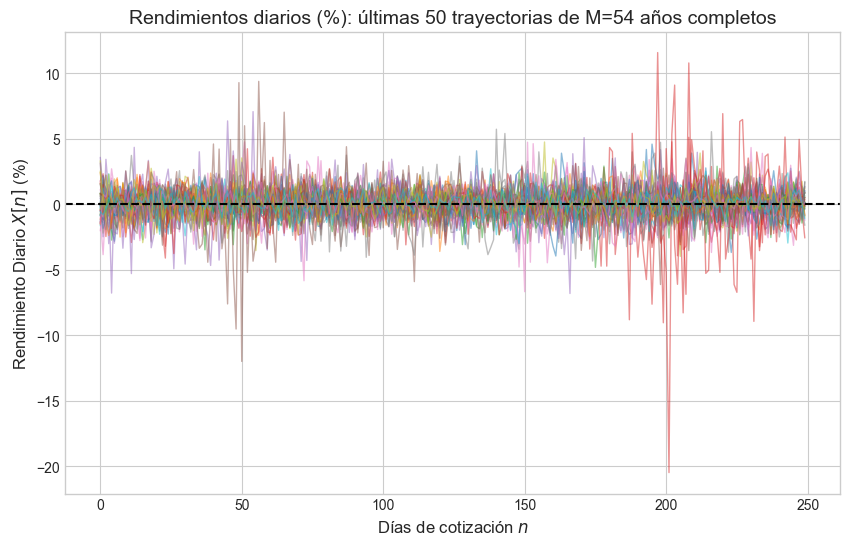

In [7]:
# 1. Descarga de datos
ticker = '^GSPC'
df_sp500 = yf.download(ticker, start='1970-01-01', end='2025-12-31')

# Usamos la columna 'Close' para el cierre diario
if isinstance(df_sp500.columns, pd.MultiIndex):
    precios = df_sp500['Close'].squeeze()
else:
    precios = df_sp500['Close']

# Cálculo de los rendimientos diarios en porcentaje (se elimina el primer valor nulo)
rendimientos = precios.pct_change().dropna() * 100

# 2. Ensamble de trayectorias (misma idea que en la caminata aleatoria: M realizaciones homogéneas)
# Solo entran años con al menos N_dias sesiones reales. Así evitamos el "padding con 0":
# rellenar con ceros no es un rendimiento de mercado y sesga media y varianza hacia el final del año.
N_dias = 250
years_all = list(range(1970, 2026))
filas = []
years_ok = []
for year in years_all:
    datos = rendimientos[rendimientos.index.year == year].values
    if len(datos) >= N_dias:
        years_ok.append(year)
        filas.append(datos[:N_dias])

X = np.vstack(filas)
M = X.shape[0]
omitidos = sorted(set(years_all) - set(years_ok))
print(f"Ensamble rendimientos: M={M} años con ≥{N_dias} sesiones. Omitidos ({len(omitidos)}): {omitidos}")

# Visualización de un subconjunto de trayectorias (ej. últimas 50 realizaciones)
plt.figure(figsize=(10, 6))
for i in range(max(0, M - 50), M):
    plt.plot(range(N_dias), X[i, :], alpha=0.5, lw=1)

plt.title(f"Rendimientos diarios (%): últimas 50 trayectorias de M={M} años completos", fontsize=14)
plt.xlabel('Días de cotización $n$', fontsize=12)
plt.ylabel('Rendimiento Diario $X[n]$ (%)', fontsize=12)
plt.axhline(0.0, color='black', linestyle='--')
plt.show()


# **Reto 5**
Repita los Retos 1, 2, 3 y 4 aplicando el código sobre la nueva matriz X (rendimientos) y analise los resultados. ¿Puede decir que este nuevo proceso es (aproximadamente) WSS?

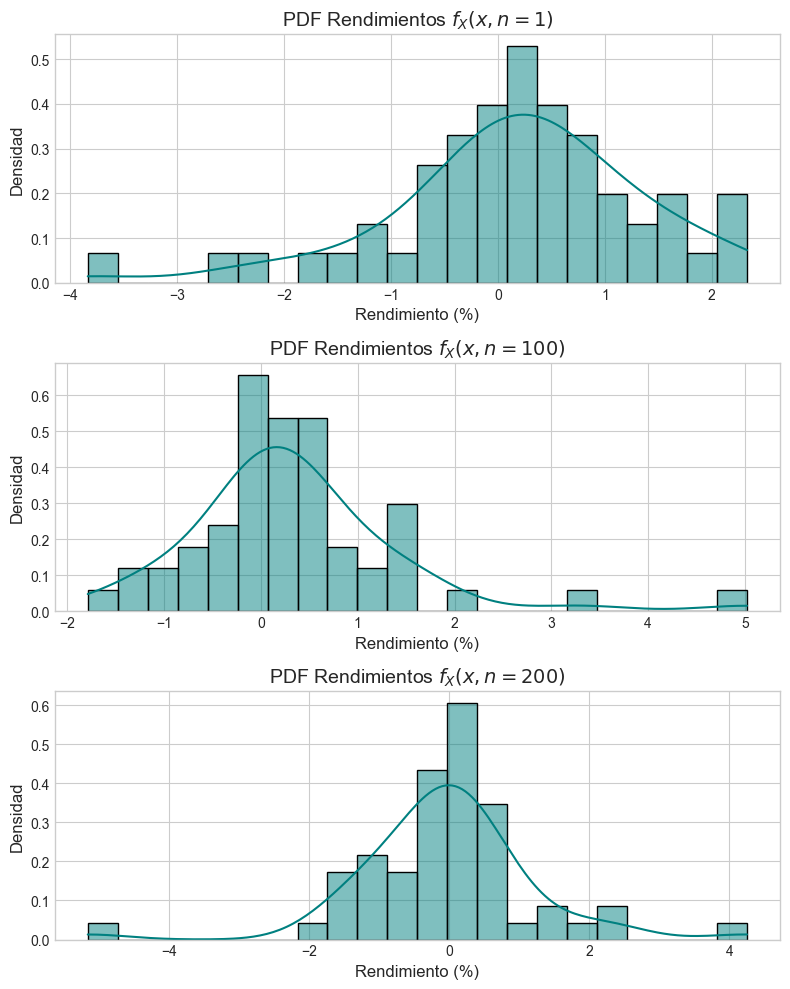

ρ entre pares de rendimientos X[n], X[m] (años completos):
  ρ(X[1], X[100]) = 0.035785
  ρ(X[1], X[200]) = -0.197758
  ρ(X[100], X[200]) = -0.093820


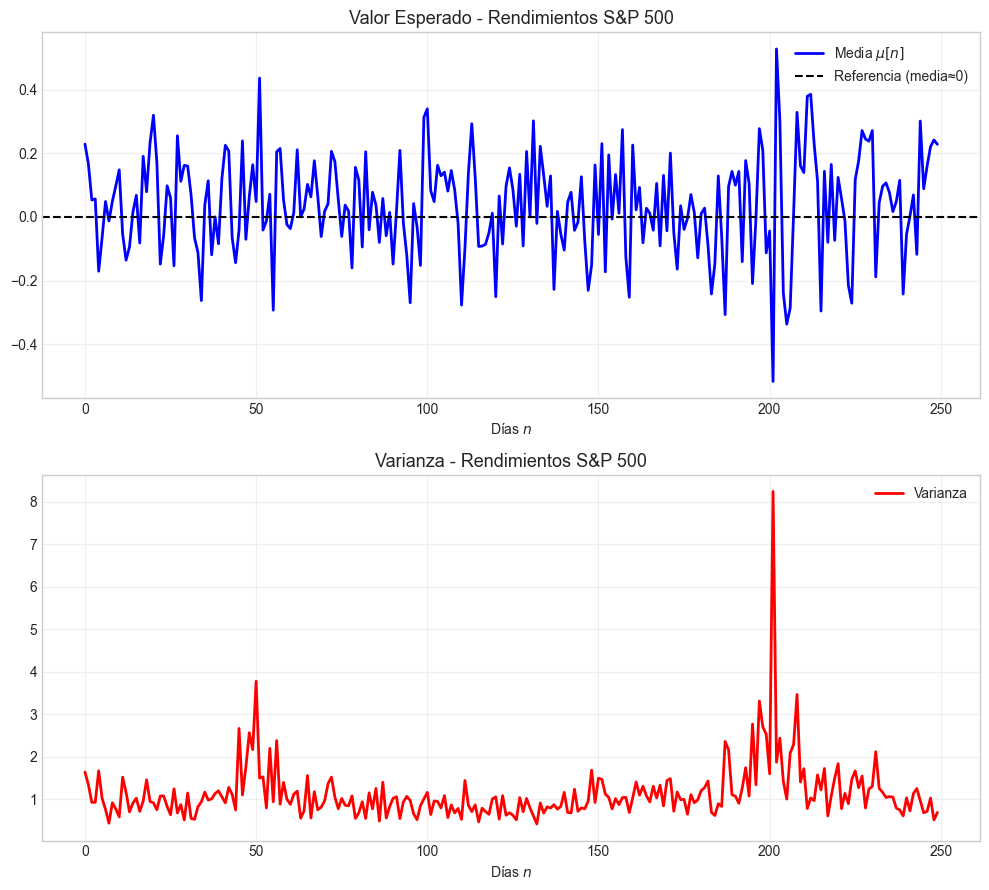

ρ(n, μ[n]) = 0.009436
ρ(n, Var(X[n])) = 0.157728


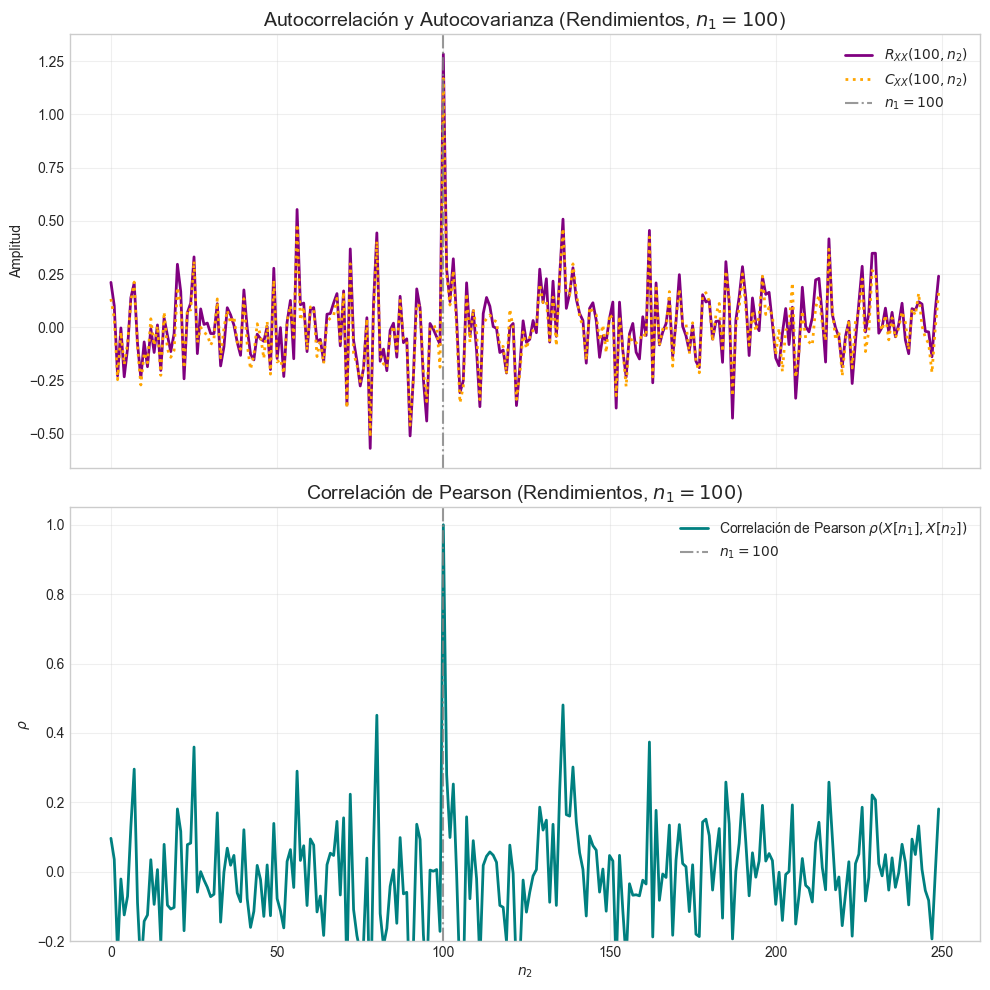

Verificación: C_XX(100,100)=1.168104, Var(X[100])=1.168104
¿Coinciden? True
  n2=0: ρ=0.096406, C/(σ·σ)=0.096406
  n2=50: ρ=-0.077252, C/(σ·σ)=-0.077252
  n2=150: ρ=0.046904, C/(σ·σ)=0.046904
  n2=249: ρ=0.181191, C/(σ·σ)=0.181191


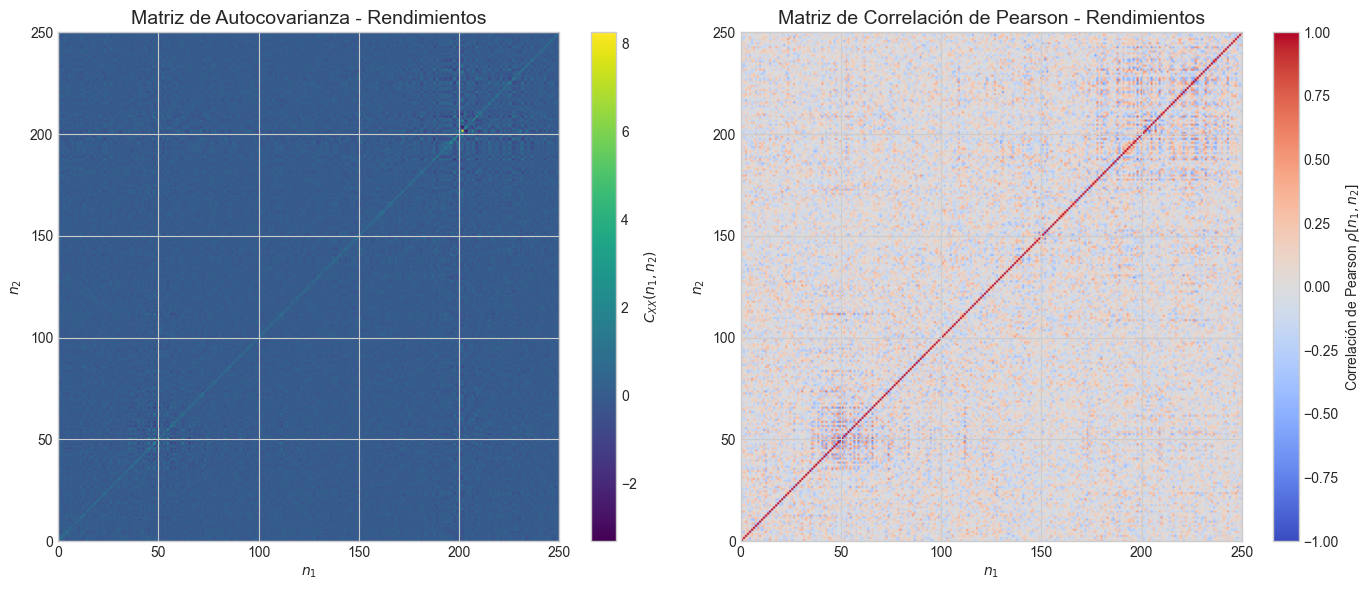

In [8]:
# Reto 5: Repetir Retos 1, 2, 3 y 4 con la matriz X de RENDIMIENTOS
# (X = rendimientos %; ensamble solo de años con ≥250 sesiones — sin padding con ceros)

# ========== Reto 1 (Rendimientos): PDF para n=1, 100, 200 ==========
n_valores = [1, 100, 200]
fig, axes = plt.subplots(3, 1, figsize=(8, 10))
for i, n in enumerate(n_valores):
    X_en_n = X[:, n]
    sns.histplot(X_en_n, kde=True, stat="density", ax=axes[i], color='teal', bins=22)
    axes[i].set_title(f'PDF Rendimientos $f_X(x, n={n})$', fontsize=14)
    axes[i].set_xlabel('Rendimiento (%)', fontsize=12)
    axes[i].set_ylabel('Densidad', fontsize=12)
plt.tight_layout()
plt.show()
# Pearson entre pares (transversal), convención poblacional ddof=0
def _rho_poblacional_r(u, v):
    su, sv = np.std(u, ddof=0), np.std(v, ddof=0)
    if su * sv <= 1e-20:
        return float("nan")
    return np.mean((u - u.mean()) * (v - v.mean())) / (su * sv)

idx_pdf = [1, 100, 200]
print("ρ entre pares de rendimientos X[n], X[m] (años completos):")
for ia, a in enumerate(idx_pdf):
    for b in idx_pdf[ia + 1 :]:
        ra, rb = X[:, a], X[:, b]
        print(f"  ρ(X[{a}], X[{b}]) = {_rho_poblacional_r(ra, rb):.6f}")

# ========== Reto 2 (Rendimientos): Valor esperado y varianza ==========
mu_rend = np.mean(X, axis=0)
var_rend = np.var(X, axis=0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9))
ax1.plot(range(N_dias), mu_rend, label=r'Media $\mu[n]$', color='blue', lw=2)
ax1.axhline(0.0, color='black', linestyle='--', label='Referencia (media≈0)')
ax1.set_title('Valor Esperado - Rendimientos S&P 500', fontsize=13)
ax1.set_xlabel('Días $n$')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(range(N_dias), var_rend, label='Varianza', color='red', lw=2)
ax2.set_title('Varianza - Rendimientos S&P 500', fontsize=13)
ax2.set_xlabel('Días $n$')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_f = np.arange(N_dias, dtype=float)
print(f"ρ(n, μ[n]) = {np.corrcoef(n_f, mu_rend)[0, 1]:.6f}")
print(f"ρ(n, Var(X[n])) = {np.corrcoef(n_f, var_rend)[0, 1]:.6f}")

# ========== Reto 3 (Rendimientos): Autocorrelación, autocovarianza y Pearson n1=100 ==========
n1 = 100
R_XX_rend = np.zeros(N_dias)
C_XX_rend = np.zeros(N_dias)
rho_rend = np.full(N_dias, np.nan)
for n2 in range(N_dias):
    R_XX_rend[n2] = np.mean(X[:, n1] * X[:, n2])
    C_XX_rend[n2] = R_XX_rend[n2] - (mu_rend[n1] * mu_rend[n2])
    s1 = np.std(X[:, n1], ddof=0)
    s2 = np.std(X[:, n2], ddof=0)
    if s1 > 1e-20 and s2 > 1e-20:
        rho_rend[n2] = C_XX_rend[n2] / (s1 * s2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
ax1.plot(range(N_dias), R_XX_rend, label=r'$R_{XX}(100, n_2)$', color='purple', lw=2)
ax1.plot(range(N_dias), C_XX_rend, label=r'$C_{XX}(100, n_2)$', color='orange', linestyle=':', lw=2)
ax1.axvline(n1, color='gray', linestyle='-.', alpha=0.8, label=f'$n_1 = {n1}$')
ax1.set_title(f'Autocorrelación y Autocovarianza (Rendimientos, $n_1=100$)', fontsize=14)
ax1.set_ylabel('Amplitud')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(range(N_dias), rho_rend, label=r'Correlación de Pearson $\rho(X[n_1], X[n_2])$', color='teal', lw=2)
ax2.axvline(n1, color='gray', linestyle='-.', alpha=0.8, label=f'$n_1 = {n1}$')
ax2.set_title(f'Correlación de Pearson (Rendimientos, $n_1=100$)', fontsize=14)
ax2.set_xlabel('$n_2$')
ax2.set_ylabel(r'$\rho$')
ax2.set_ylim(-0.2, 1.05)
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Verificación: C_XX(100,100)={C_XX_rend[n1]:.6f}, Var(X[100])={var_rend[n1]:.6f}")
print(f"¿Coinciden? {np.isclose(C_XX_rend[n1], var_rend[n1])}")
std_n1r = np.std(X[:, n1], ddof=0)
for n_test in (0, 50, 150, 249):
    st = np.std(X[:, n_test], ddof=0)
    if st > 1e-20:
        print(f"  n2={n_test}: ρ={rho_rend[n_test]:.6f}, C/(σ·σ)={C_XX_rend[n_test]/(std_n1r*st):.6f}")

# ========== Reto 4 (Rendimientos): Matriz de autocovarianza y Pearson ==========
C_XX_matriz_rend = np.cov(X, rowvar=False, ddof=0)
sig_r = np.sqrt(np.clip(np.diag(C_XX_matriz_rend), 1e-30, None))
Rho_matriz_rend = C_XX_matriz_rend / np.outer(sig_r, sig_r)
np.fill_diagonal(Rho_matriz_rend, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im0 = axes[0].imshow(C_XX_matriz_rend, origin='lower', cmap='viridis',
                     extent=[0, N_dias, 0, N_dias], aspect='auto')
plt.colorbar(im0, ax=axes[0], label=r'$C_{XX}(n_1, n_2)$')
axes[0].set_xlabel('$n_1$')
axes[0].set_ylabel('$n_2$')
axes[0].set_title('Matriz de Autocovarianza - Rendimientos', fontsize=14)

im1 = axes[1].imshow(Rho_matriz_rend, origin='lower', cmap='coolwarm', vmin=-1, vmax=1,
                     extent=[0, N_dias, 0, N_dias], aspect='auto')
plt.colorbar(im1, ax=axes[1], label=r'Correlación de Pearson $\rho[n_1, n_2]$')
axes[1].set_xlabel('$n_1$')
axes[1].set_ylabel('$n_2$')
axes[1].set_title('Matriz de Correlación de Pearson - Rendimientos', fontsize=14)
plt.tight_layout()
plt.show()


### Análisis — Reto 5 (rendimientos: repetición y WSS aproximado)

**Retos 1–2 (rendimientos):** Las PDFs en distintos $n$ son mucho más parecidas entre sí que en el caso de precios: forma aproximadamente simétrica y centrada cerca de cero. Tras usar **solo años completos** (sin padding con ceros), $\mu[n]$ y la varianza suelen verse **más estables** que antes; pueden quedar variaciones leves por **posición dentro del año calendario** (efectos estacionales) y por fluctuaciones de muestreo con $M$ finito.

**Retos 3–4:** Sigue cumpliéndose $C_{XX}(100,100)\approx \mathrm{var}\{X[100]\}$. La matriz de autocovarianza de rendimientos tiende a ser más **diagonal-dominante** que la de precios (correlaciones entre días distintos más pequeñas en magnitud típica), coherente con rendimientos diarios casi incorrelacionados.

**¿WSS aproximado?** Frente a los **precios**, los rendimientos se acercan más al esquema WSS: media cercana a **cero** y PDFs más estables en $n$. **No** es un WSS estricto en este ensamble: el índice $n$ sigue siendo el **día dentro del año**, la varianza puede variar algo con $n$ y la autocovarianza no tiene por qué reducirse a una función exacta solo de $n_2-n_1$. En finanzas se usa a menudo una **aproximación** de estacionariedad en ventanas cortas.

**Pearson en el Reto 5:** se repite el mismo criterio que arriba: pares $(n,m)$ en las PDFs, $\rho(n,\mu[n])$ y $\rho(n,\mathrm{Var})$ para ver estabilidad frente al día del año, curva $\rho(100,n_2)$ coherente con $C_{XX}/(\sigma_{100}\sigma_{n_2})$, y *heatmap* $\rho_{n_1,n_2}$ deducido de la matriz de covarianza poblacional (diagonal 1).

